In [67]:
import pandas as pd
import joblib
import numpy as np
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [68]:
df = pd.read_csv("forex_dataset_clean.csv")

data = df[["EURUSD"]].dropna()

print("Data shape:", data.shape)
print(data)

Data shape: (1300, 1)
        EURUSD
0     1.216841
1     1.219363
2     1.217285
3     1.218200
4     1.217256
...        ...
1295  1.164890
1296  1.163548
1297  1.162210
1298  1.160941
1299  1.152738

[1300 rows x 1 columns]


In [69]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)

In [70]:
joblib.dump(scaler, "eurusd_scaler.pkl")

['eurusd_scaler.pkl']

In [71]:
# 3. Create sequences
# -----------------------
X = []
y = []


lookback = 30

for i in range(lookback, len(scaled)):
    X.append(scaled[i-lookback:i, 0])
    y.append(scaled[i, 0])

X = np.array(X)
y = np.array(y)

print("Length of scaled:", len(scaled))
print("Length of X:", len(X))
print("Length of y:", len(y))





from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(X_train.shape)
print(X_test.shape)




Length of scaled: 1300
Length of X: 1270
Length of y: 1270
(1016, 30, 1)
(254, 30, 1)


In [72]:
# reshape for LSTM
X = X.reshape((X.shape[0], X.shape[1], 1))

print("X shape:", X.shape)

X shape: (1270, 30, 1)


In [73]:
# 4. Build LSTM model
# -----------------------
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(LSTM(50))

model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")

C:\Users\PC\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [74]:
# 5. Train model
# -----------------------
#model.fit(X, y, epochs=10, batch_size=16)
model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_test, y_test)
)


Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.0191 - val_loss: 0.0059
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0023 - val_loss: 0.0015
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0020 - val_loss: 0.0012
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0019 - val_loss: 0.0014
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0018 - val_loss: 0.0010
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0016 - val_loss: 0.0013
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0015 - val_loss: 9.2731e-04
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0014 - val_loss: 0.0010
Epoch 9/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0013 - val_loss: 0.0014
Epoch 10/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0012 - val_loss: 8.3029e-04
Epoch 11/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0012 - val_loss: 0.0022
Epoch 12/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - l

In [75]:
# 6. Predict next value
# -----------------------
last_30 = scaled[-lookback:]
input_data = last_30.reshape(1, lookback, 1)

pred = model.predict(input_data)
pred_price = scaler.inverse_transform(pred)
print(pred)
print("\n Predicted EURUSD Price:", pred_price[0][0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step
[[0.7429959]]

 Predicted EURUSD Price: 1.152608


In [76]:
# 7. Direction (simple logic)
# -----------------------
current = data.iloc[-1].values[0]

if pred_price[0][0] > current:
    print(" BULLISH")
else:
    print(" BEARISH")


 BEARISH


In [77]:
model.save("eurusd_model.h5")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


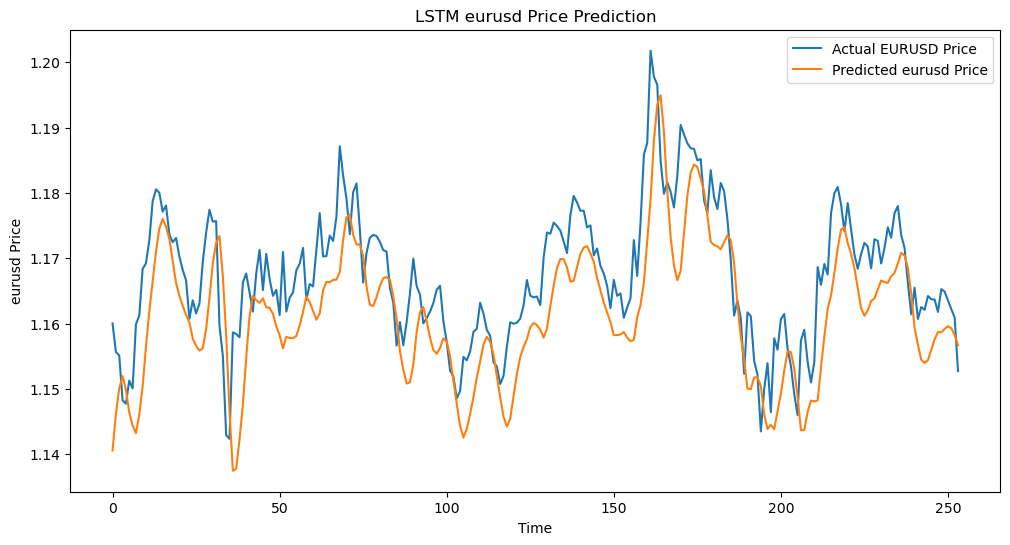

In [78]:
import matplotlib.pyplot as plt

# Predict on test set
predictions = model.predict(X_test)

# Convert back to real prices
predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y_test.reshape(-1,1))

plt.figure(figsize=(12,6))
plt.plot(actual, label="Actual EURUSD Price")
plt.plot(predictions, label="Predicted eurusd Price")

plt.title("LSTM eurusd Price Prediction")
plt.xlabel("Time")
plt.ylabel("eurusd Price")
plt.legend()

plt.show()


In [79]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(actual, predictions))
mae = mean_absolute_error(actual, predictions)

print("RMSE:", rmse)
print("MAE :", mae)

RMSE: 0.008618459737915703
MAE : 0.007117013292988466
